In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, warnings
from scipy.stats import pearsonr

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

import shap
%matplotlib inline
warnings.filterwarnings('ignore')


In [2]:
BASE_DIR = "../"
DATA_PATH = os.path.join(BASE_DIR, "data", "cancer_data_eng.csv")
IMG_DIR = os.path.join(BASE_DIR, "img")
RESULTS_DIR = os.path.join(BASE_DIR, "results")

os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
RANDOM_STATE = 42
N_SAMPLES = 10000

In [3]:
print("\n[0] 加载数据...")
df = pd.read_csv(DATA_PATH, low_memory=False, encoding='latin-1')
df['target'] = df['Status.Vital'].map({'VIVO': 1, 'MORTO': 0})
df = df.dropna(subset=['target'])
np.random.seed(RANDOM_STATE)
if len(df) > N_SAMPLES:
    idx = np.random.choice(len(df), N_SAMPLES, replace=False)
    df = df.iloc[idx].copy()

feature_cols = ['Age', 'year', 'Code.Profession', 'Diagnostic.means',
                'Extension', 'Raca.Color']
df_feat = df[feature_cols + ['target']].copy()

cat_cols = ['Diagnostic.means', 'Extension', 'Raca.Color']
for col in cat_cols:
    le = LabelEncoder()
    non_null = df_feat[col].dropna().astype(str)
    le.fit(non_null)
    mc = non_null.value_counts().index[0]
    def encode(x, le=le, mc=mc):
        if pd.isna(x): return np.nan
        xs = str(x)
        return le.transform([xs])[0] if xs in le.classes_ else le.transform([mc])[0]
    df_feat[col] = df_feat[col].apply(encode)

X = df_feat[feature_cols].astype(float).values
y = df_feat['target'].values
feature_names = np.array(feature_cols)

print(f"    总样本: {len(X):,}  VIVO: {y.sum():,} ({y.mean()*100:.2f}%)")

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)

imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()
X_tr_imp = imputer.fit_transform(X_tr)
X_te_imp = imputer.transform(X_te)
X_tr_final = scaler.fit_transform(X_tr_imp)
X_te_final = scaler.transform(X_te_imp)



[0] 加载数据...
    总样本: 10,000  VIVO: 4,123.0 (41.23%)


# 1. 训练模型 + SHAP 计算

In [4]:
print("\n[1] 训练模型 + SHAP 计算...")
model = RandomForestClassifier(
    n_estimators=200, max_depth=8, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1)
model.fit(X_tr_final, y_tr)
y_prob = model.predict_proba(X_te_final)[:, 1]
auc = roc_auc_score(y_te, y_prob)
print(f"    RF AUC = {auc:.4f}")

# SHAP
n_shap = 500
X_shap = X_te_final[:n_shap]
explainer = shap.TreeExplainer(model)
shap_values_full = explainer.shap_values(X_shap)

# 取正类 (VIVO) 的 SHAP 值
if isinstance(shap_values_full, list):
    sv = shap_values_full[1]
else:
    sv = shap_values_full
    if sv.ndim == 3:
        sv = sv[:, :, 1]

shap_importance = np.abs(sv).mean(0)
feature_order = np.argsort(shap_importance)[::-1]  # 从大到小
print(f"    SHAP 值形状: {sv.shape}")
print(f"    特征排名: {[feature_names[i] for i in feature_order]}")


[1] 训练模型 + SHAP 计算...
    RF AUC = 0.9104
    SHAP 值形状: (500, 6)
    特征排名: [np.str_('Diagnostic.means'), np.str_('year'), np.str_('Raca.Color'), np.str_('Extension'), np.str_('Code.Profession'), np.str_('Age')]


# 2. 高级依赖图 — 二次多项式拟合 + R²

  Diagnostic.means           R²_lin=0.8569  R²_quad=0.9518  ΔR²=+0.0948  ↑ 非线性  | 交互特征: Raca.Color
  year                       R²_lin=0.6649  R²_quad=0.7618  ΔR²=+0.0969  ↑ 非线性  | 交互特征: Diagnostic.means
  Raca.Color                 R²_lin=0.8021  R²_quad=0.8042  ΔR²=+0.0021  ≈ 线性  | 交互特征: Diagnostic.means
  Extension                  R²_lin=0.6873  R²_quad=0.8298  ΔR²=+0.1424  ↑ 非线性  | 交互特征: Diagnostic.means
  Code.Profession            R²_lin=0.8015  R²_quad=0.8028  ΔR²=+0.0012  ≈ 线性  | 交互特征: Raca.Color
  Age                        R²_lin=0.7613  R²_quad=0.7871  ΔR²=+0.0258  ↑ 非线性  | 交互特征: Code.Profession
  [图] 16a_dependence_quad_1~6_*.png 已保存


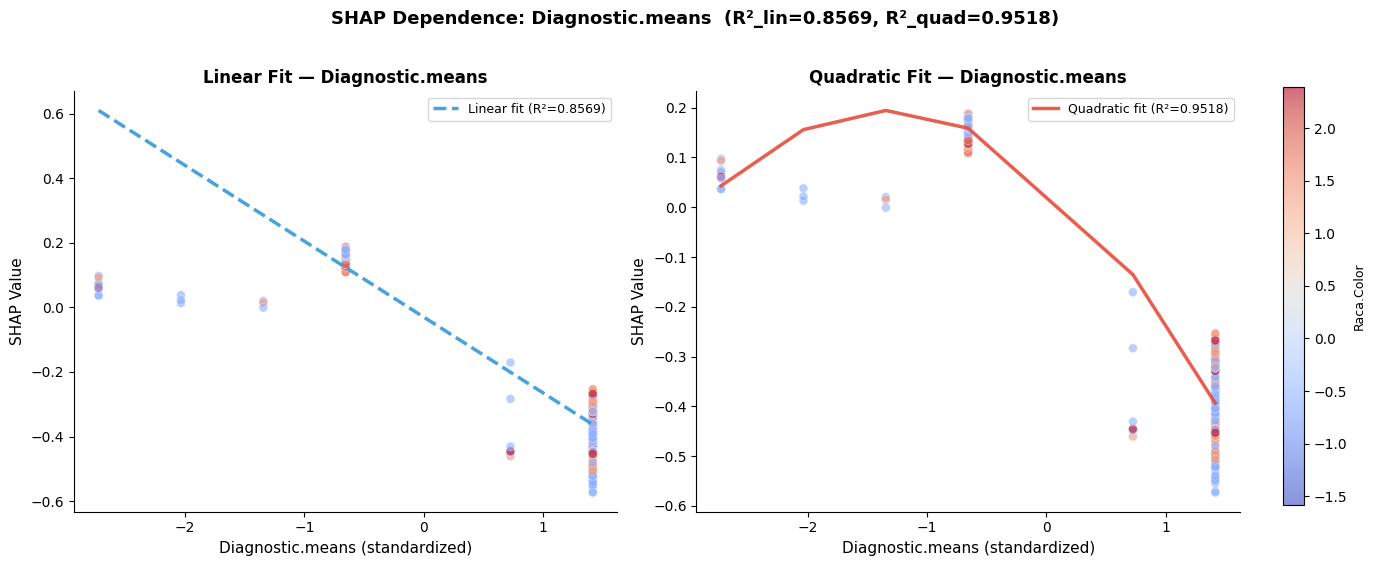

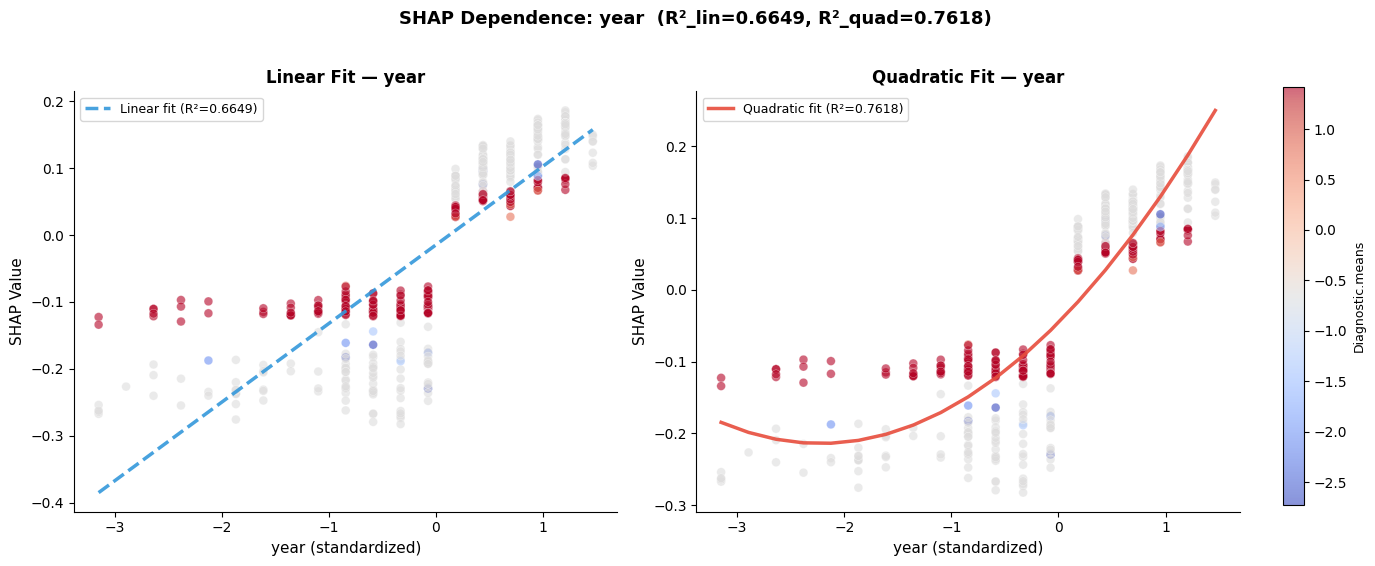

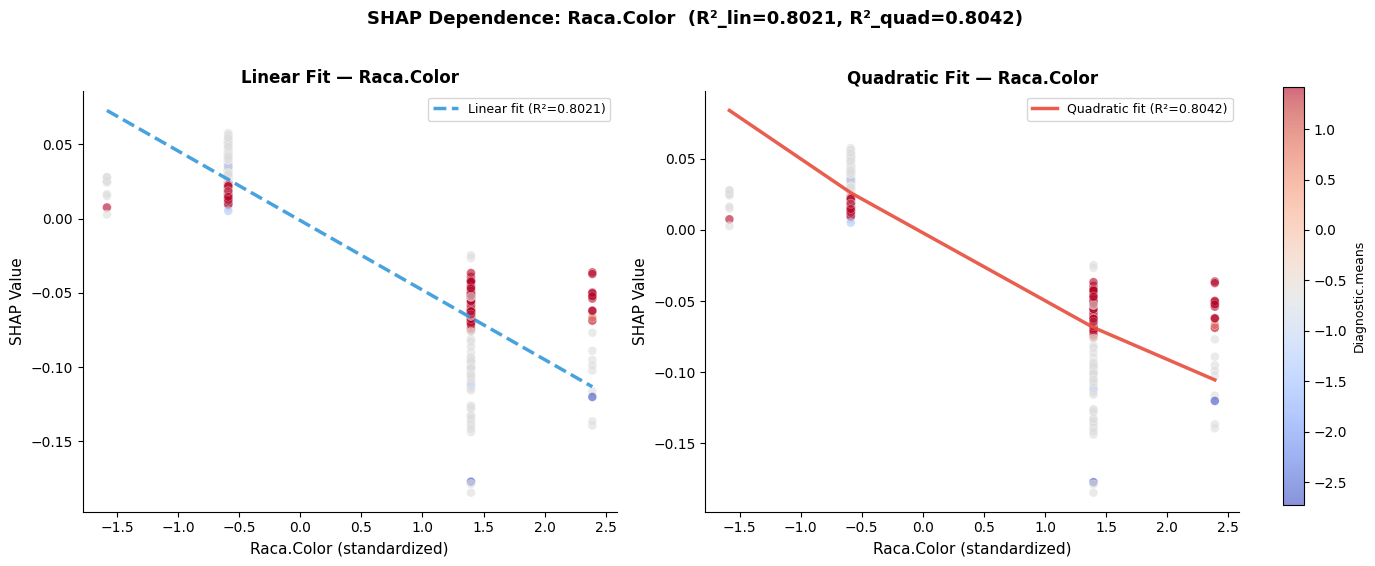

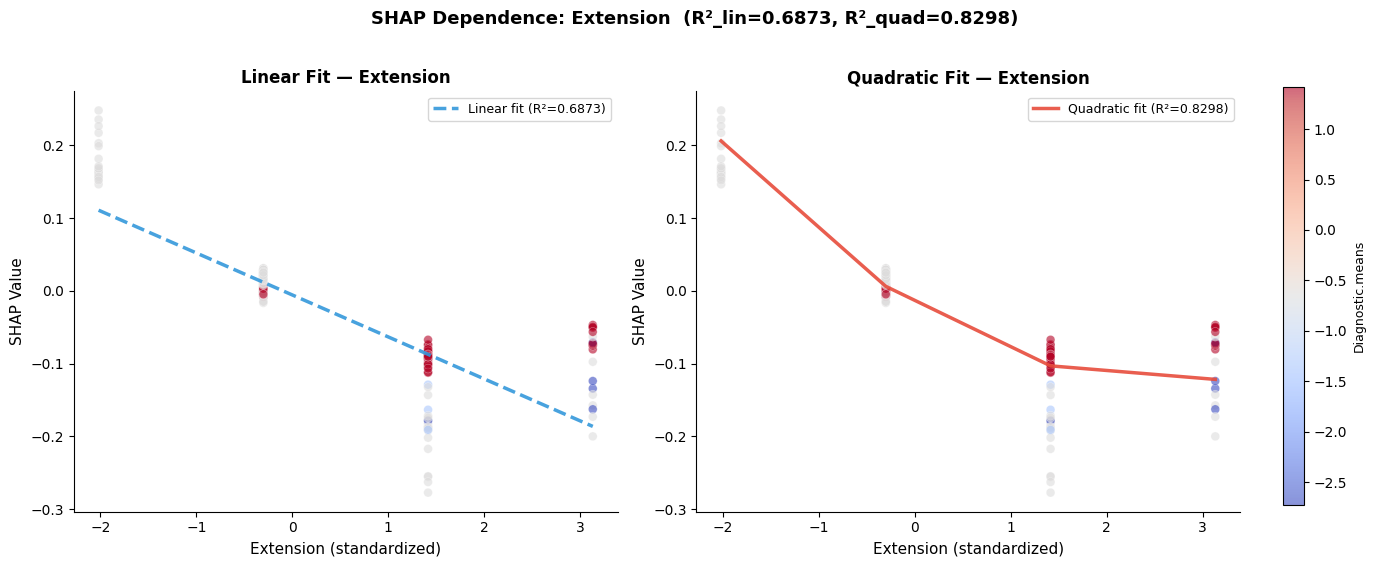

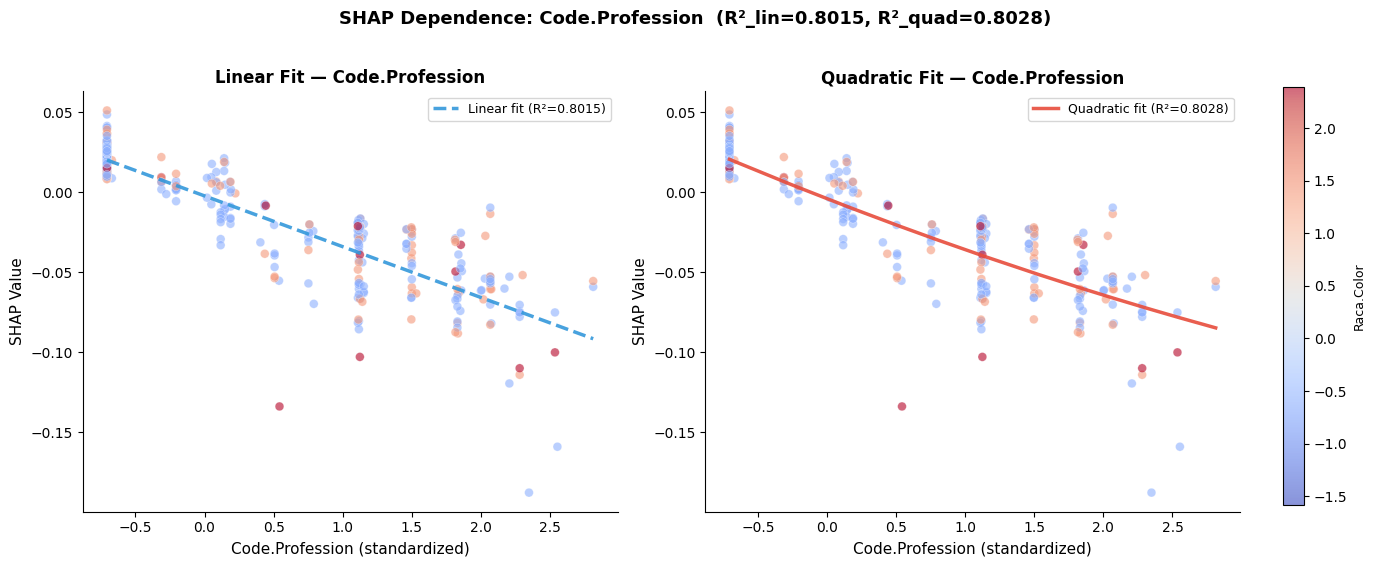

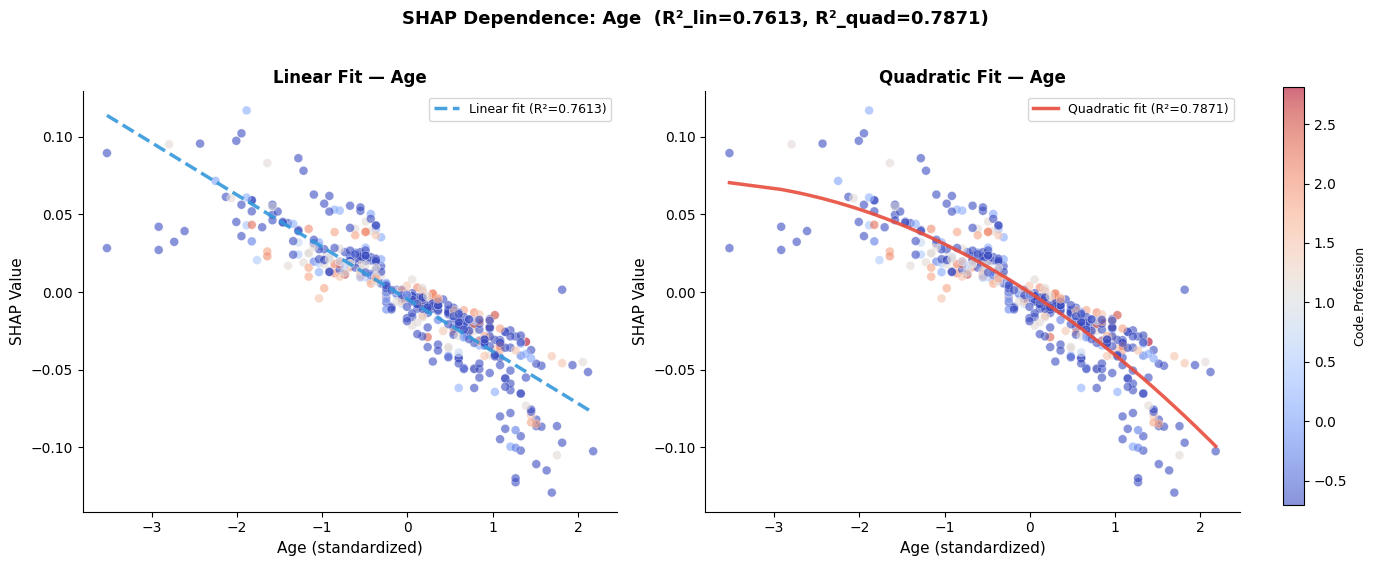

In [5]:
top_n_dep = 6  # Top 6 特征

for rank, idx in enumerate(feature_order[:top_n_dep]):
    fn = feature_names[idx]
    x_vals = X_shap[:, idx]
    y_vals = sv[:, idx]

    # 找交互特征
    correlations = []
    for j in range(X_shap.shape[1]):
        if j != idx:
            corr, _ = pearsonr(X_shap[:, j], y_vals)
            correlations.append((j, abs(corr)))
    interaction_idx = max(correlations, key=lambda x: x[1])[0]

    # 二次多项式拟合
    z2 = np.polyfit(x_vals, y_vals, 2)
    p2 = np.poly1d(z2)

    # 计算 R² (二次拟合)
    y_pred_quad = p2(x_vals)
    ss_res = np.sum((y_vals - y_pred_quad) ** 2)
    ss_tot = np.sum((y_vals - np.mean(y_vals)) ** 2)
    r2_quad = 1 - ss_res / ss_tot

    # 线性拟合 (对比)
    z1 = np.polyfit(x_vals, y_vals, 1)
    p1 = np.poly1d(z1)
    y_pred_lin = p1(x_vals)
    ss_res_lin = np.sum((y_vals - y_pred_lin) ** 2)
    r2_lin = 1 - ss_res_lin / ss_tot

    # 批量依赖图: 每行两个特征, 分 3 行
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    for ax_i, (use_poly, deg, label) in enumerate([
        (False, 1, 'Linear'),
        (True, 2, 'Quadratic')
    ]):
        ax = axes[ax_i]
        scatter = ax.scatter(x_vals, y_vals, c=X_shap[:, interaction_idx],
                             cmap='coolwarm', alpha=0.6, s=40, edgecolors='white', linewidth=0.3)

        x_sorted = np.sort(x_vals)

        if use_poly:
            # 二次拟合 + 置信区间 (bootstrap 模拟)
            y_fit = p2(x_sorted)
            r2 = r2_quad
            color_fit = '#e74c3c'
            ls = '-'
        else:
            y_fit = p1(x_sorted)
            r2 = r2_lin
            color_fit = '#3498db'
            ls = '--'

        ax.plot(x_sorted, y_fit, color=color_fit, linestyle=ls,
                linewidth=2.5, alpha=0.9,
                label=f'{label} fit (R²={r2:.4f})')

        ax.set_xlabel(f'{fn} (standardized)', fontsize=11)
        ax.set_ylabel('SHAP Value', fontsize=11)
        ax.set_title(f'{label} Fit — {fn}',
                     fontsize=12, fontweight='bold')
        ax.legend(fontsize=9, loc='best')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # 添加颜色条
    cbar_ax = fig.add_axes([0.92, 0.12, 0.015, 0.76])
    cbar = fig.colorbar(scatter, cax=cbar_ax)
    cbar.set_label(feature_names[interaction_idx], fontsize=9)

    plt.suptitle(f'SHAP Dependence: {fn}  (R²_lin={r2_lin:.4f}, R²_quad={r2_quad:.4f})',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.savefig(os.path.join(IMG_DIR, f"16a_dependence_quad_{rank+1}_{fn}.png"),
                dpi=150, bbox_inches='tight')
    # plt.close()

    # 打印 R² 对比
    delta_r2 = r2_quad - r2_lin
    print(f"  {fn:<25}  R²_lin={r2_lin:.4f}  R²_quad={r2_quad:.4f}  ΔR²={delta_r2:+.4f}"
          f"  {'↑ 非线性' if delta_r2 > 0.01 else '≈ 线性'}  "
          f"| 交互特征: {feature_names[interaction_idx]}")

print(f"  [图] 16a_dependence_quad_1~6_*.png 已保存")

# 3. 3D 特征空间分布

  [图] 16b_3d_shap_space.png 已保存


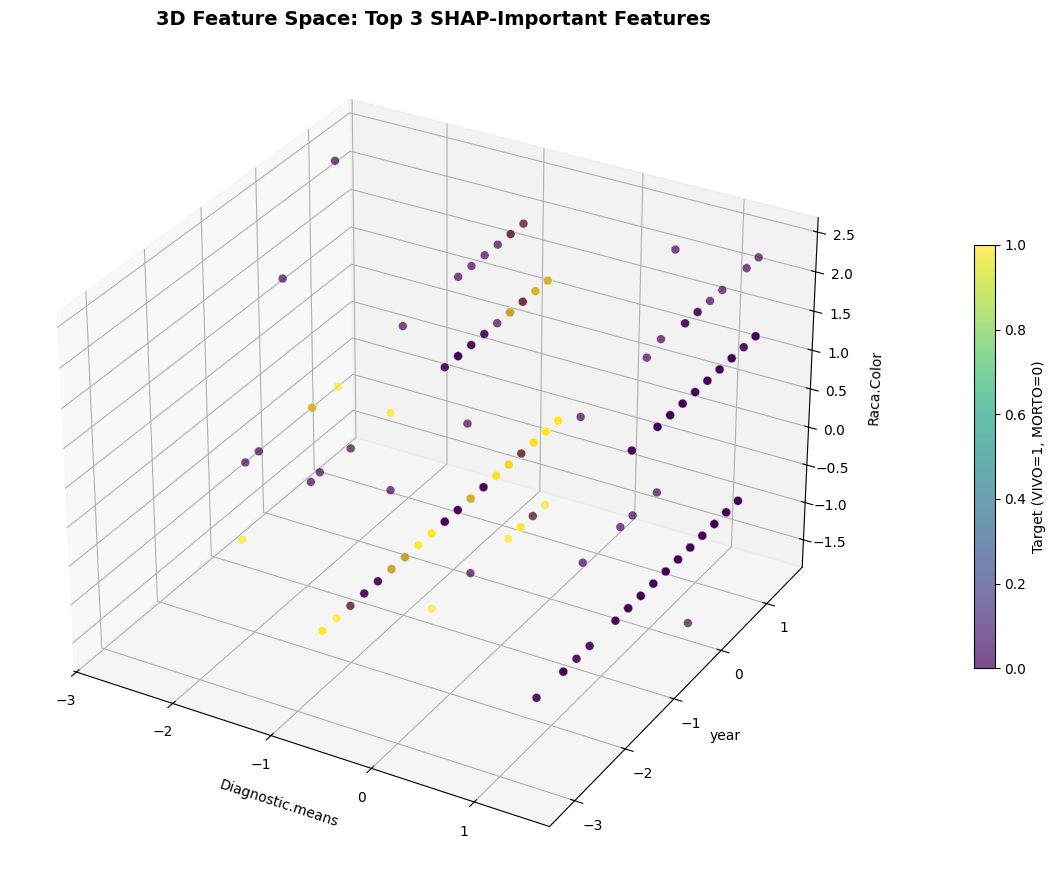

In [6]:
top3_idx = feature_order[:3]

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

y_shap_sub = y_te[:n_shap]
scatter_3d = ax.scatter(
    X_shap[:, top3_idx[0]], X_shap[:, top3_idx[1]], X_shap[:, top3_idx[2]],
    c=y_shap_sub, cmap='viridis', s=40, alpha=0.7, edgecolors='white', linewidth=0.3)

ax.set_xlabel(feature_names[top3_idx[0]], fontsize=10, labelpad=8)
ax.set_ylabel(feature_names[top3_idx[1]], fontsize=10, labelpad=8)
ax.set_zlabel(feature_names[top3_idx[2]], fontsize=10, labelpad=8)
ax.set_title('3D Feature Space: Top 3 SHAP-Important Features',
             fontsize=14, fontweight='bold')
cbar_3d = plt.colorbar(scatter_3d, ax=ax, shrink=0.5, pad=0.1)
cbar_3d.set_label('Target (VIVO=1, MORTO=0)', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "16b_3d_shap_space.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 16b_3d_shap_space.png 已保存")


[4] SHAP 力量矩阵热图
  [图] 16c_shap_force_matrix.png 已保存


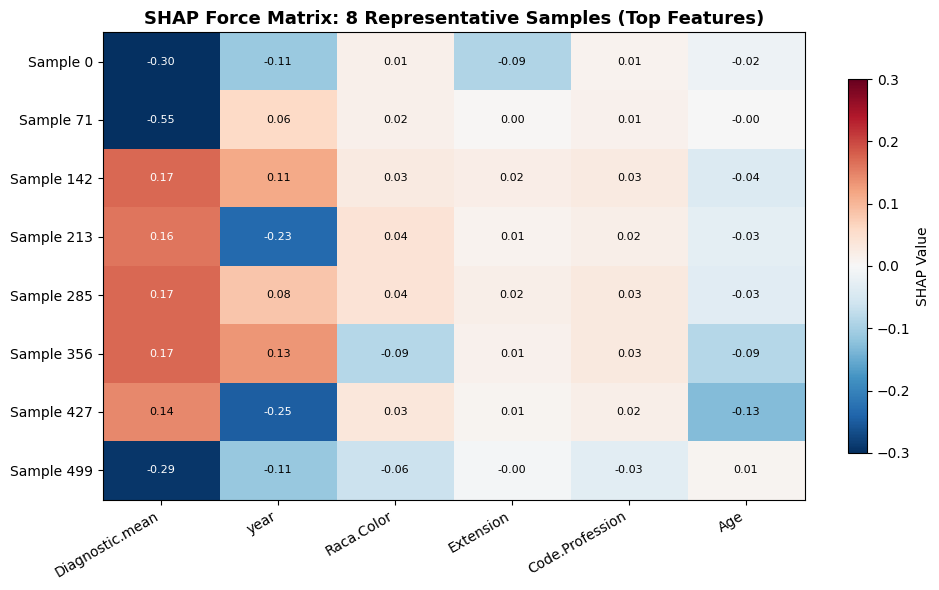

In [7]:
# ============================================================================
# 4. SHAP 力量矩阵热图 (代表性样本)
# ============================================================================
print("\n" + "=" * 70)
print("[4] SHAP 力量矩阵热图")
print("=" * 70)

n_samples = 8
sample_indices = np.linspace(0, len(X_shap) - 1, n_samples, dtype=int)

top_n_heat = min(10, len(feature_names))
top_heat_idx = feature_order[:top_n_heat]

force_matrix = np.zeros((n_samples, top_n_heat))
for i, sidx in enumerate(sample_indices):
    force_matrix[i] = sv[sidx, top_heat_idx]

fig, ax = plt.subplots(figsize=(10, 6))
im_heat = ax.imshow(force_matrix, cmap='RdBu_r', aspect='auto', vmin=-0.3, vmax=0.3)

ax.set_xticks(range(top_n_heat))
ax.set_xticklabels([feature_names[i][:15] for i in top_heat_idx], rotation=30, ha='right')
ax.set_yticks(range(n_samples))
ax.set_yticklabels([f'Sample {sidx}' for sidx in sample_indices])

# 添加数值标注
for i in range(n_samples):
    for j in range(top_n_heat):
        val = force_matrix[i, j]
        color = 'white' if abs(val) > 0.15 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color=color)

ax.set_title('SHAP Force Matrix: 8 Representative Samples (Top Features)',
             fontsize=13, fontweight='bold')
plt.colorbar(im_heat, ax=ax, label='SHAP Value', shrink=0.8)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "16c_shap_force_matrix.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 16c_shap_force_matrix.png 已保存")


[5] 特征重要性分组饼图
  [图] 16d_shap_group_pie.png 已保存


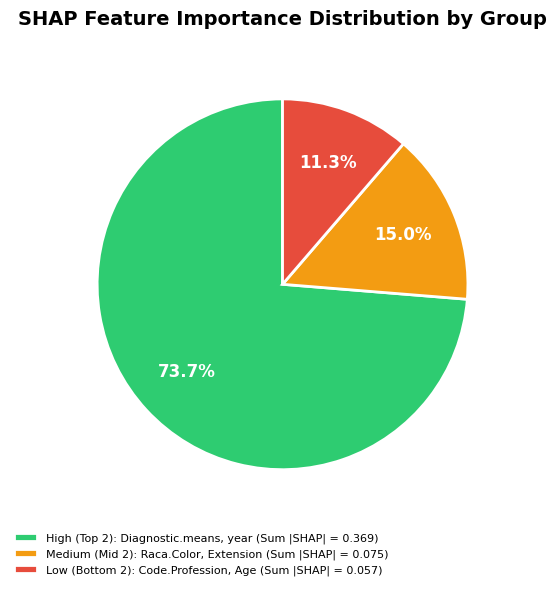

In [8]:
# ============================================================================
# 5. 特征重要性分组饼图
# ============================================================================
print("\n" + "=" * 70)
print("[5] 特征重要性分组饼图")
print("=" * 70)

n_features = len(feature_names)
sorted_imp = np.sort(shap_importance)[::-1]
high_idx = feature_order[:n_features // 3]
mid_idx = feature_order[n_features // 3: 2 * n_features // 3]
low_idx = feature_order[2 * n_features // 3:]

group_importance = [
    np.sum(shap_importance[high_idx]),
    np.sum(shap_importance[mid_idx]),
    np.sum(shap_importance[low_idx])
]

group_labels = [
    f'High (Top {len(high_idx)}): ' + ', '.join(feature_names[high_idx]),
    f'Medium (Mid {len(mid_idx)}): ' + ', '.join(feature_names[mid_idx]),
    f'Low (Bottom {len(low_idx)}): ' + ', '.join(feature_names[low_idx])
]

colors_group = ['#2ecc71', '#f39c12', '#e74c3c']

fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(
    group_importance, labels=None,
    colors=colors_group, autopct='%1.1f%%',
    startangle=90, pctdistance=0.7,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

# 手动添加图例
legend_texts = [f'{group_labels[i]} (Sum |SHAP| = {group_importance[i]:.3f})'
                for i in range(3)]
ax.legend(wedges, legend_texts, loc='lower left', bbox_to_anchor=(-0.1, -0.15),
          fontsize=8, frameon=False)
ax.set_title('SHAP Feature Importance Distribution by Group',
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "16d_shap_group_pie.png"),
            dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 16d_shap_group_pie.png 已保存")


[6] SHAP 值变化趋势 (按预测概率排序)
  [图] 16e_shap_trend.png 已保存


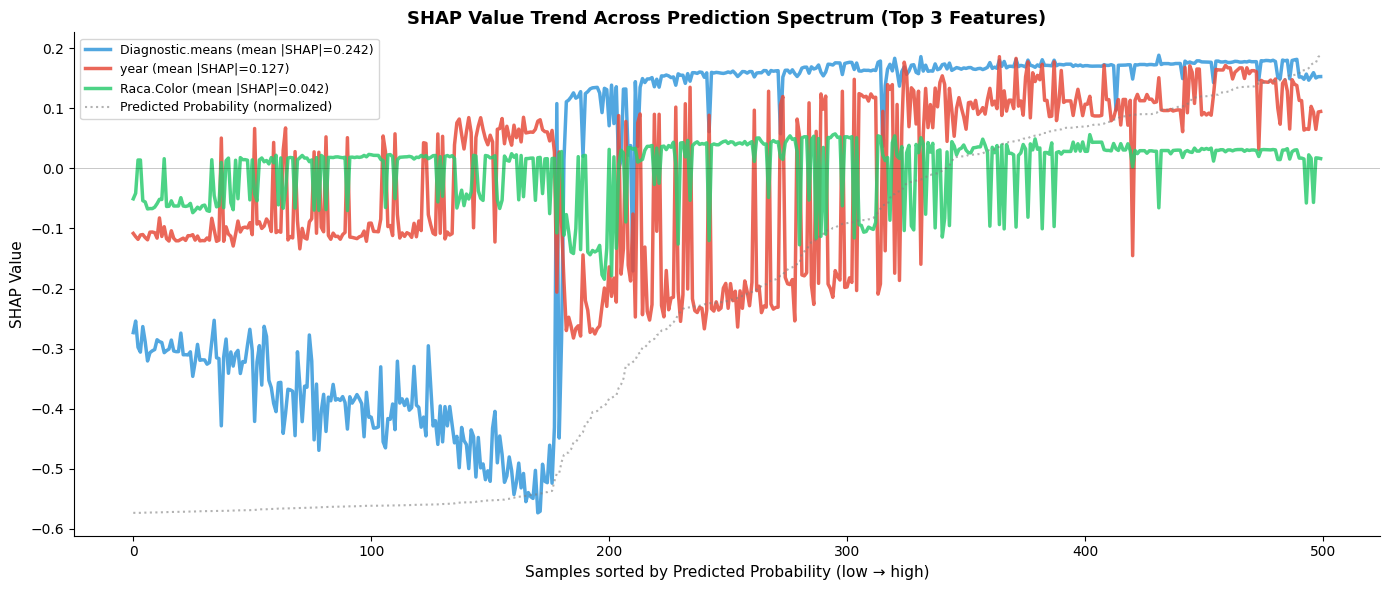

In [9]:
# ============================================================================
# 6. SHAP 值变化趋势 (按预测概率排序)
# ============================================================================
print("\n" + "=" * 70)
print("[6] SHAP 值变化趋势 (按预测概率排序)")
print("=" * 70)

# 按预测概率排序
y_prob_shap = model.predict_proba(X_shap)[:, 1]
sorted_order = np.argsort(y_prob_shap)

top_trend_idx = feature_order[:3]  # Top 3 特征

fig, ax = plt.subplots(figsize=(14, 6))
colors_trend = ['#3498db', '#e74c3c', '#2ecc71']

for i, feat_idx in enumerate(top_trend_idx):
    ax.plot(sv[sorted_order, feat_idx],
            color=colors_trend[i], linewidth=2.5, alpha=0.85,
            label=f'{feature_names[feat_idx]} (mean |SHAP|={shap_importance[feat_idx]:.3f})')

# 添加平均预测概率曲线作为参考
prob_norm = (y_prob_shap[sorted_order] - y_prob_shap.min()) / (y_prob_shap.max() - y_prob_shap.min())
prob_shifted = prob_norm * (sv[:, top_trend_idx[0]].max() - sv[:, top_trend_idx[0]].min()) + sv[:, top_trend_idx[0]].min()
ax.plot(prob_shifted, color='gray', linewidth=1.5, linestyle=':', alpha=0.6,
        label='Predicted Probability (normalized)')

ax.set_xlabel('Samples sorted by Predicted Probability (low → high)', fontsize=11)
ax.set_ylabel('SHAP Value', fontsize=11)
ax.set_title('SHAP Value Trend Across Prediction Spectrum (Top 3 Features)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='best')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.axhline(y=0, color='black', linewidth=0.5, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "16e_shap_trend.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 16e_shap_trend.png 已保存")


[7] 特征交互网络图
  [图] 16f_shap_network.png 已保存

  交互矩阵 (|Pearson r|):
                 Diagnostic      yearRaca.Color ExtensionCode.Profe       Age
  Diagnostic.m     0.000     0.178     0.177     0.200     0.020     0.007
  year             0.178     0.000     0.022     0.074     0.054     0.057
  Raca.Color       0.177     0.022     0.000     0.110     0.162     0.041
  Extension        0.200     0.074     0.110     0.000     0.149     0.151
  Code.Profess     0.020     0.054     0.162     0.149     0.000     0.073
  Age              0.007     0.057     0.041     0.151     0.073     0.000


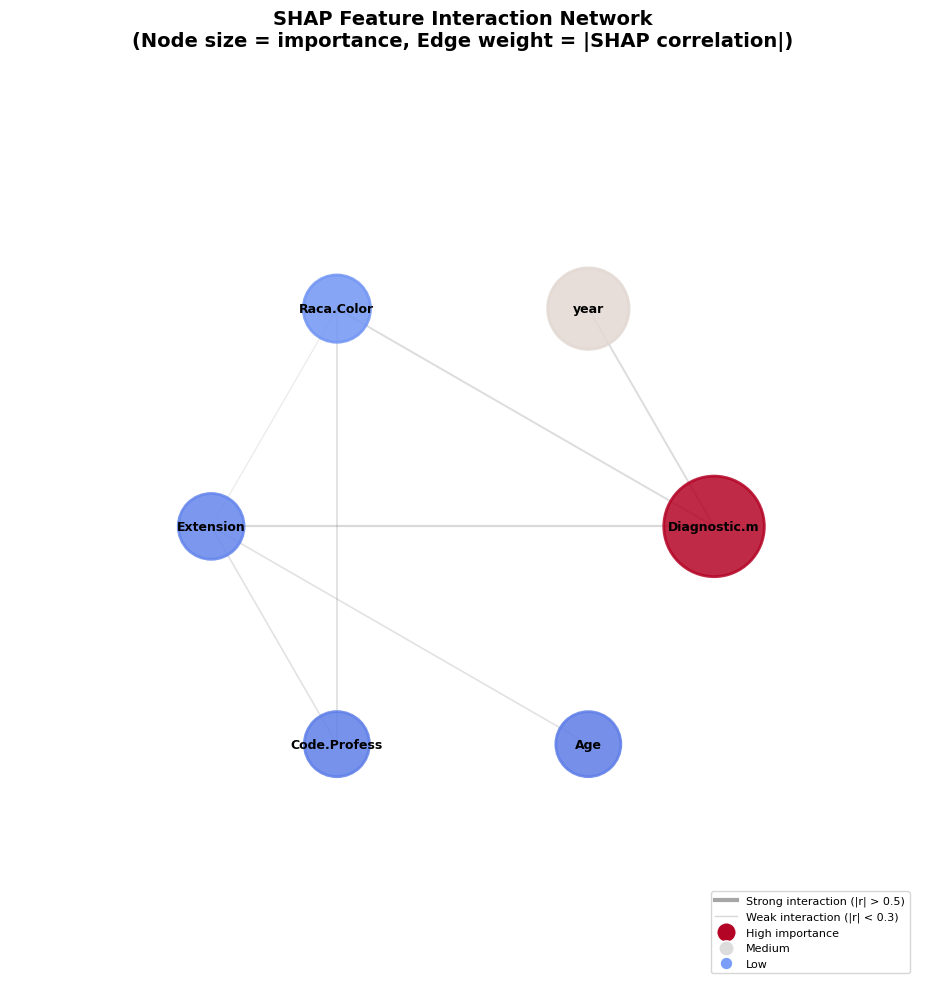

In [10]:
# ============================================================================
# 7. 特征交互网络图
# ============================================================================
print("\n" + "=" * 70)
print("[7] 特征交互网络图")
print("=" * 70)

top_n_net = min(8, len(feature_names))
top_net_idx = feature_order[:top_n_net]

# 计算交互矩阵 (SHAP 值相关性)
interaction_matrix = np.zeros((top_n_net, top_n_net))
for i in range(top_n_net):
    for j in range(top_n_net):
        if i != j:
            idx1, idx2 = top_net_idx[i], top_net_idx[j]
            corr, _ = pearsonr(sv[:, idx1], sv[:, idx2])
            interaction_matrix[i, j] = abs(corr)

# 圆形布局
angles = np.linspace(0, 2 * np.pi, top_n_net, endpoint=False)
pos = np.column_stack([np.cos(angles), np.sin(angles)])

fig, ax = plt.subplots(figsize=(10, 10))

# 绘制边
max_interaction = interaction_matrix.max() if interaction_matrix.max() > 0 else 1
for i in range(top_n_net):
    for j in range(i + 1, top_n_net):
        strength = interaction_matrix[i, j]
        if strength > 0.1:  # 只显示有意义的交互
            ax.plot([pos[i, 0], pos[j, 0]], [pos[i, 1], pos[j, 1]],
                    color='gray', alpha=min(strength * 1.5, 0.9),
                    linewidth=strength * 8, zorder=1)

# 绘制节点
for i in range(top_n_net):
    node_size = shap_importance[top_net_idx[i]] / shap_importance.max()
    circle = plt.Circle(pos[i], 0.12 + node_size * 0.08,
                        color=plt.cm.coolwarm(node_size),
                        alpha=0.85, zorder=2, edgecolor='white', linewidth=2)
    ax.add_patch(circle)
    ax.text(pos[i, 0], pos[i, 1],
            f'{feature_names[top_net_idx[i]][:12]}',
            ha='center', va='center', fontsize=9, fontweight='bold', zorder=3)

# 添加图例
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='gray', linewidth=3, alpha=0.7, label='Strong interaction (|r| > 0.5)'),
    Line2D([0], [0], color='gray', linewidth=1, alpha=0.3, label='Weak interaction (|r| < 0.3)'),
]
# 节点大小图例
for imp_level, sz_label in [(1.0, 'High importance'), (0.5, 'Medium'), (0.2, 'Low')]:
    legend_elements.append(
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor=plt.cm.coolwarm(imp_level),
               markersize=8 + imp_level * 6, label=sz_label))

ax.legend(handles=legend_elements, loc='lower right', fontsize=8, framealpha=0.8)
ax.set_xlim([-1.8, 1.8])
ax.set_ylim([-1.8, 1.8])
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('SHAP Feature Interaction Network\n(Node size = importance, Edge weight = |SHAP correlation|)',
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "16f_shap_network.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 16f_shap_network.png 已保存")

# 打印交互矩阵文本
print("\n  交互矩阵 (|Pearson r|):")
print(f"  {'':<15}", end='')
for i in range(top_n_net):
    print(f'{feature_names[top_net_idx[i]][:10]:>10}', end='')
print()
for i in range(top_n_net):
    print(f'  {feature_names[top_net_idx[i]][:12]:<12}', end='')
    for j in range(top_n_net):
        print(f'{interaction_matrix[i,j]:>10.3f}', end='')
    print()


[8] SHAP 值分位数分布
  [图] 16g_shap_quantiles.png 已保存


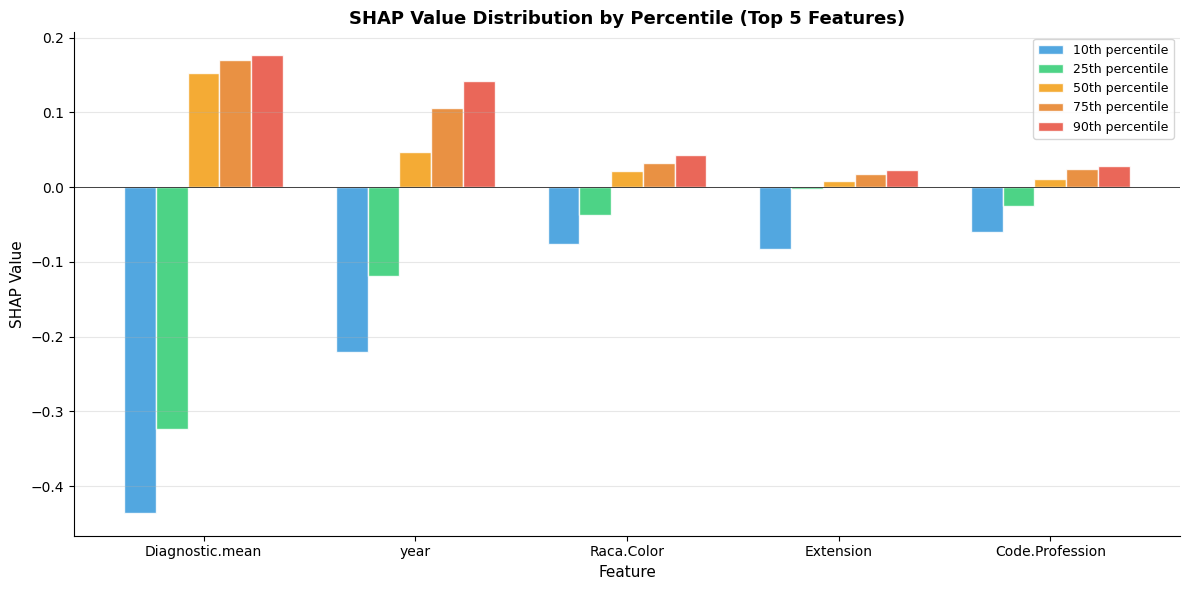

In [12]:
# ============================================================================
# 8. SHAP 值分位数分布
# ============================================================================
print("\n" + "=" * 70)
print("[8] SHAP 值分位数分布")
print("=" * 70)

quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]
top5_idx = feature_order[:5]

quantile_data = []
for idx in top5_idx:
    q_values = [np.quantile(sv[:, idx], q) for q in quantiles]
    quantile_data.append(q_values)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(top5_idx))
width = 0.15
colors_q = ['#3498db', '#2ecc71', '#f39c12', '#e67e22', '#e74c3c']

for i, q in enumerate(quantiles):
    values = [quantile_data[j][i] for j in range(len(top5_idx))]
    bars = ax.bar(x + i * width, values, width,
                  label=f'{int(q * 100)}th percentile',
                  color=colors_q[i], alpha=0.85, edgecolor='white')

ax.set_xlabel('Feature', fontsize=11)
ax.set_ylabel('SHAP Value', fontsize=11)
ax.set_title('SHAP Value Distribution by Percentile (Top 5 Features)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels([feature_names[idx][:15] for idx in top5_idx], fontsize=10)
ax.legend(fontsize=9)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "16g_shap_quantiles.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 16g_shap_quantiles.png 已保存")
